In [22]:
# IMPORT ALL PROJECT MODULES

from ball_observation import BallObservation
from ball_trajectory import Ball, simulate_n_balls
from particle_filter import ParticleFilter
from nball_particle_filter import NBallParticleFilter
import importlib
import plotting
importlib.reload(plotting)

from plotting import (
    BallTrajectoryPlot,
    BallObservationPlot,
    ParticleFilterTrajectoryPlot,
    nBallTrajectoryPlot
)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation



TIME STEP|| TRAJECTORY(x,y)1:
------------------------------
t= 0.00s || (  0.00,   0.00)
t= 0.10s || (  5.73,   3.92)
t= 0.20s || ( 11.47,   7.74)
t= 0.30s || ( 17.20,  11.46)
t= 0.40s || ( 22.94,  15.08)
t= 0.50s || ( 28.67,  18.60)
t= 0.60s || ( 34.40,  22.03)
t= 0.70s || ( 40.14,  25.36)
t= 0.80s || ( 45.87,  28.59)
t= 0.90s || ( 51.61,  31.72)
t= 1.00s || ( 57.34,  34.75)
t= 1.10s || ( 63.07,  37.69)
t= 1.20s || ( 68.81,  40.53)
t= 1.30s || ( 74.54,  43.27)
t= 1.40s || ( 80.28,  45.91)
t= 1.50s || ( 86.01,  48.45)
t= 1.60s || ( 91.75,  50.90)
t= 1.70s || ( 97.48,  53.25)
t= 1.80s || (103.21,  55.50)
t= 1.90s || (108.95,  57.65)
t= 2.00s || (114.68,  59.70)
t= 2.10s || (120.42,  61.65)
t= 2.20s || (126.15,  63.51)
t= 2.30s || (131.88,  65.27)
t= 2.40s || (137.62,  66.93)
t= 2.50s || (143.35,  68.49)
t= 2.60s || (149.09,  69.96)
t= 2.70s || (154.82,  71.32)
t= 2.80s || (160.55,  72.59)
t= 2.90s || (166.29,  73.76)
t= 3.00s || (172.02,  74.83)
t= 3.10s || (177.76,  75.81)
t= 3.20s |

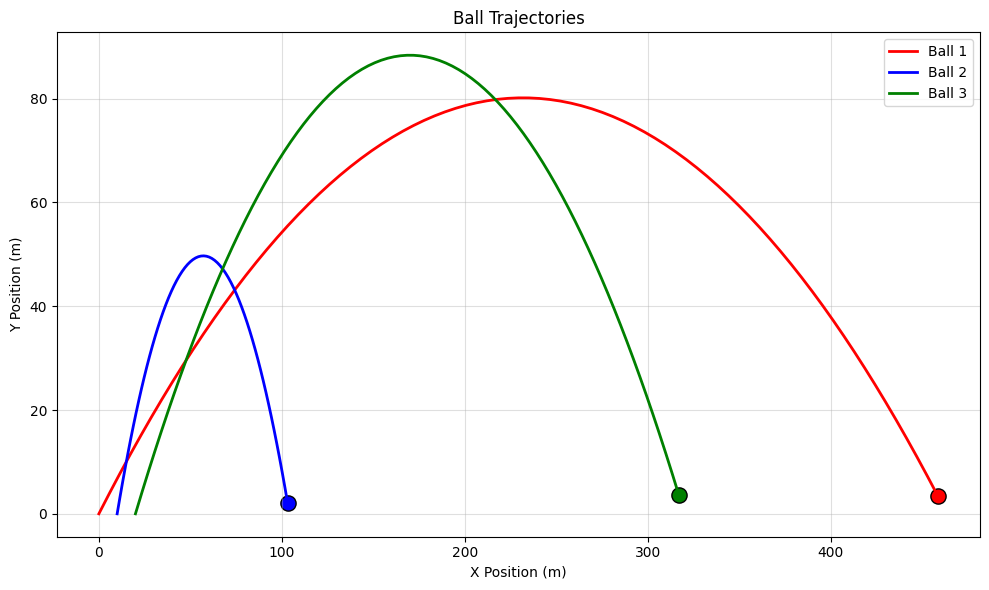

In [23]:

SAMPLE_SETS = {
        1: [  # Different angles, wide separation 
            {"initial_position": [0,  0], "speed": 50, "angle_degrees": 45},
            {"initial_position": [20, 0], "speed": 60, "angle_degrees": 30},
        ],
        2: [  # Steep vs shallow 
            {"initial_position": [0,  0], "speed": 55, "angle_degrees": 75},
            {"initial_position": [15, 0], "speed": 45, "angle_degrees": 25},
        ],
        3: [  # Similar speeds and angles 
            {"initial_position": [0, 0], "speed": 50, "angle_degrees": 45},
            {"initial_position": [5, 0], "speed": 52, "angle_degrees": 47},
        ],
        4: [  # Fast vs slow, different heights
            {"initial_position": [0,  0], "speed": 70, "angle_degrees": 35},
            {"initial_position": [10, 0], "speed": 35, "angle_degrees": 65},
            {"initial_position": [20, 0], "speed": 55, "angle_degrees": 50},
        ],
    }

SAMPLE = 4      
launches = SAMPLE_SETS[SAMPLE]
DT           = 0.1


trajectories = simulate_n_balls(launches, dt=DT)
for i, traj in enumerate(trajectories):
    print(f"\nTIME STEP|| TRAJECTORY(x,y){i+1}:")
    print("------------------------------")
    for t, x, y in traj:
        print(f"t={t:5.2f}s || ({x:6.2f}, {y:6.2f})")
# Visualize trajectory
plotter = BallTrajectoryPlot(launches)
plotter.visualize()

TIME STEP || BALL 1 ||
           || Obs. (x,y) ||
---------------------------------------------------------------

Ball 1:
t= 0.00s || ( -2.90,   1.92)
t= 0.10s || (  5.16,   3.77)
t= 0.20s || ( 16.29,   8.90)
t= 0.30s || ( 13.94,  13.63)
t= 0.40s || ( 25.58,  12.28)
t= 0.50s || ( 26.47,  15.42)
t= 0.60s || ( 27.98,  29.27)
t= 0.70s || ( 43.20,  23.74)
t= 0.80s || ( 43.91,  25.54)
t= 0.90s || ( 53.99,  33.69)
t= 1.00s || ( 58.12,  34.10)
t= 1.10s || ( 64.60,  35.78)
t= 1.20s || ( 72.43,  39.73)
t= 1.30s || ( 72.90,  43.38)
t= 1.40s || ( 79.31,  48.79)
t= 1.50s || ( 88.48,  49.43)
t= 1.60s || ( 96.72,  51.78)
t= 1.70s || ( 98.56,  50.54)
t= 1.80s || (100.79,  60.20)
t= 1.90s || Observation Dropped
t= 2.00s || (112.91,  60.71)
t= 2.10s || (112.65,  55.44)
t= 2.20s || (119.63,  60.95)
t= 2.30s || (137.33,  65.98)
t= 2.40s || (141.32,  68.76)
t= 2.50s || (145.74,  67.42)
t= 2.60s || (148.03,  70.63)
t= 2.70s || (150.80,  68.91)
t= 2.80s || (162.70,  76.18)
t= 2.90s || (169.48,  72.07)
t= 

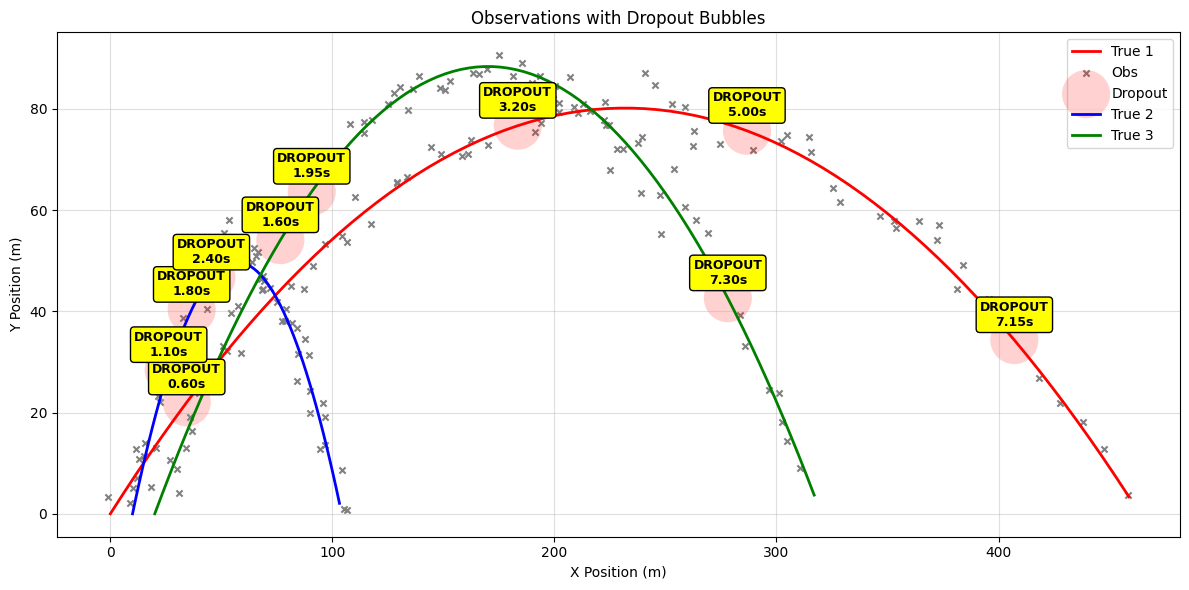

In [24]:
#BallObservation

NOISE_STDDEV = 3.0
DROPOUT_PROB = 0.02
observers     = [BallObservation(traj, noise_stddev=NOISE_STDDEV, dropout_prob=DROPOUT_PROB)
                     for traj in trajectories]
obs_sequences = [obs.simulate_observations() for obs in observers]
print("===============================================================")
print("TIME STEP || BALL 1 ||")
print("           || Obs. (x,y) ||")
print("---------------------------------------------------------------")

for i, obs in enumerate(observers):
    print(f"\nBall {i + 1}:")
    observations = obs.simulate_observations()
    for t, position in observations:
        if position is not None:
            print(f"t={t:5.2f}s || ({position[0]:6.2f}, {position[1]:6.2f})")
        else:
            print(f"t={t:5.2f}s || Observation Dropped")
    
plotter = BallObservationPlot(trajectories, noise_stddev=3.0, dropout_prob=0.2)
plotter.visualize()

Initializing 5000 particles for 3 balls in area 100.0x100.0
TIME STEP ||             BALL 0              ||             BALL 1              ||             BALL 2              ||
          ||     Obs.       |      Est.      ||     Obs.       |      Est.      ||     Obs.       |      Est.      ||
---------------------------------------------------------------------------------------------------------------------
t= 0.00s  ||      N/A       | (  18.9,   5.7)||      N/A       | (  44.4,  12.0)||(  19.6,   0.7) | (  46.8,  43.9)||
t= 0.10s  ||(   9.6,   4.3) | (  13.0,   7.5)||(   7.0,   1.3) | ( -23.5,  13.0)||      N/A       | ( -42.0,  38.4)||
t= 0.20s  ||(  14.2,   8.5) | (   4.6,   6.9)||(  10.1,   8.2) | (  23.3,   7.2)||(  23.1,   7.7) | (  22.0,  11.8)||
t= 0.30s  ||(  17.3,  14.4) | (  20.2,  12.5)||(  10.1,  10.0) | (  26.6,  10.7)||(  28.0,  12.9) | (  23.4,  17.4)||
t= 0.40s  ||(  26.4,  15.0) | (  25.8,  14.1)||(  16.8,  11.3) | (  28.2,  18.0)||(  36.8,  12.0) | (  32.0,  12.3

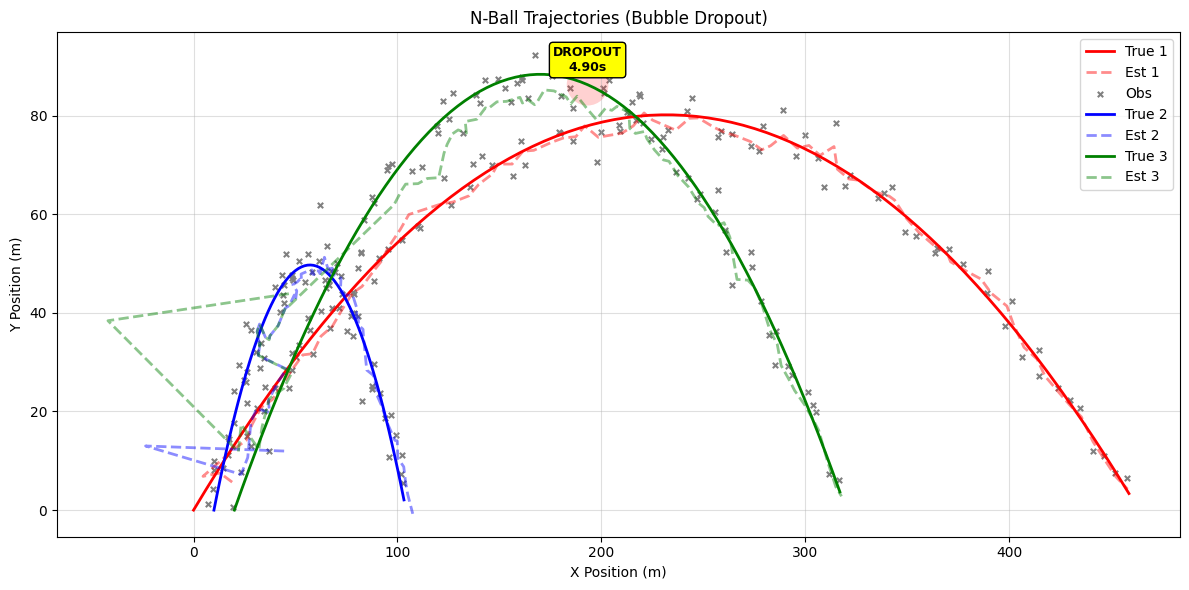

In [25]:
def assign_estimates(est: np.ndarray, true_positions: list) -> np.ndarray:
    
    assigned = np.empty_like(est)
    used = set()
    for b, tp in enumerate(true_positions):
        tp   = np.array(tp)
        best = min((j for j in range(len(est)) if j not in used),
                    key=lambda j: np.linalg.norm(est[j, :2] - tp))
        assigned[b] = est[best]
        used.add(best)
    return assigned

N_BALLS      = len(launches)

pf = NBallParticleFilter(num_particles=5000, n_balls=N_BALLS, noise_stddev=NOISE_STDDEV, area=100.0, noise=NOISE_STDDEV/2)

estimated_trajectories = {i: [] for i in range(N_BALLS)}

# Use longest sequence so no ball is cut short
n_steps = max(len(seq) for seq in obs_sequences)

_cw = 15  # width of each obs/est value cell
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'TIME STEP':^10}||" + "".join(f"{'BALL '+str(b):^{_cw*2+3}}||" for b in range(N_BALLS)))
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'':10}||" + "".join(f"{'Obs.':^{_cw}} | {'Est.':^{_cw}}||" for b in range(N_BALLS)))
print("-" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))

fmt = lambda v: f"({v[0]:6.1f},{v[1]:6.1f})" if v is not None else f"{'N/A':^{_cw}}"

for step_idx in range(n_steps):
        t        = next(obs_sequences[b][step_idx][0] for b in range(N_BALLS) if step_idx < len(obs_sequences[b]))
        obs_list = [obs_sequences[b][step_idx][1] if step_idx < len(obs_sequences[b]) else None for b in range(N_BALLS)]
        true_pos = [trajectories[b][min(step_idx, len(trajectories[b])-1)][1:3] for b in range(N_BALLS)]
        est      = assign_estimates(pf.step(dt=DT, observations=obs_list), true_pos)

        for b in range(N_BALLS):
            if step_idx < len(trajectories[b]):
                estimated_trajectories[b].append(est[b])

        print(f"t={t:5.2f}s  ||" + "".join(
            f"{fmt(obs_list[b])} | {fmt(est[b, :2] if step_idx < len(trajectories[b]) else None)}||"
            for b in range(N_BALLS)))


nBallTrajectoryPlot(
    trajectories=trajectories,
    observations=obs_sequences,
    estimates=[estimated_trajectories[i] for i in range(N_BALLS)]
).visualize()

